In [1]:
%matplotlib inline

In [30]:
from time import time
from os import path
from segysak.segy import segy_loader, get_segy_texthead, segy_header_scan, segy_header_scrape
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.geoaxes import GeoAxes
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import pyproj

from scipy.signal import butter, filtfilt



In [64]:
segy_file = path.join("..", "data", "/home/enseadamartel/Documents/OS2_dIOGO_2025/01_dados_brutos/Dados_bloco_500/projeto_bloco_500/0258_3D_SPEC_BS_4.3D.MIG_FIN.1.sgy")
print("3D", segy_file, path.exists(segy_file))

3D /home/enseadamartel/Documents/OS2_dIOGO_2025/01_dados_brutos/Dados_teste_SEGY/segy/247_Santos_part1c.sgy True


In [65]:
scan = segy_header_scan(segy_file)

with pd.option_context("display.max_rows", 100, "display.max_columns", 10):
    # drop byte locations where the mean is zero, these are likely empty.
    display(scan)

Processing Chunks:   0%|          | 0.00/1.00 [00:00<?, ? trace-chunks/s]

Reading header:   0%|          | 0.00/1.00k [00:00<?, ? traces/s]

,byte_loc,count,mean,std,min,25%,50%,75%,max
TRACE_SEQUENCE_LINE,1,1000.0,500.500,288.819436,1.0,250.75,500.5,750.25,1000.0
TRACE_SEQUENCE_FILE,5,1000.0,500.500,288.819436,1.0,250.75,500.5,750.25,1000.0
FieldRecord,9,1000.0,1214.766,1.886479,1212.0,1213.00,1215.0,1216.00,1218.0
TraceNumber,13,1000.0,70.900,44.068493,1.0,33.00,68.5,109.00,150.0
EnergySourcePoint,17,1000.0,0.000,0.000000,0.0,0.00,0.0,0.00,0.0
CDP,21,1000.0,0.000,0.000000,0.0,0.00,0.0,0.00,0.0
CDP_TRACE,25,1000.0,0.000,0.000000,0.0,0.00,0.0,0.00,0.0
TraceIdentificationCode,29,1000.0,1.000,0.536925,-1.0,1.00,1.0,1.00,7.0
NSummedTraces,31,1000.0,0.000,0.000000,0.0,0.00,0.0,0.00,0.0
NStackedTraces,33,1000.0,0.000,0.000000,0.0,0.00,0.0,0.00,0.0


In [66]:
scrape = segy_header_scrape(segy_file, partial_scan=None)

Processing Chunks:   0%|          | 0.00/1.00 [00:00<?, ? trace-chunks/s]

Reading header:   0%|          | 0.00/52.8k [00:00<?, ? traces/s]

In [6]:
scrape['CDP_Y'].unique()

array([733131089, 733132262, 733133436, ..., 732760423, 732761597,
       732762770], shape=(39291,), dtype=int32)

In [67]:
scrape.columns

Index(['TRACE_SEQUENCE_LINE', 'TRACE_SEQUENCE_FILE', 'FieldRecord',
       'TraceNumber', 'EnergySourcePoint', 'CDP', 'CDP_TRACE',
       'TraceIdentificationCode', 'NSummedTraces', 'NStackedTraces', 'DataUse',
       'offset', 'ReceiverGroupElevation', 'SourceSurfaceElevation',
       'SourceDepth', 'ReceiverDatumElevation', 'SourceDatumElevation',
       'SourceWaterDepth', 'GroupWaterDepth', 'ElevationScalar',
       'SourceGroupScalar', 'SourceX', 'SourceY', 'GroupX', 'GroupY',
       'CoordinateUnits', 'WeatheringVelocity', 'SubWeatheringVelocity',
       'SourceUpholeTime', 'GroupUpholeTime', 'SourceStaticCorrection',
       'GroupStaticCorrection', 'TotalStaticApplied', 'LagTimeA', 'LagTimeB',
       'DelayRecordingTime', 'MuteTimeStart', 'MuteTimeEND',
       'TRACE_SAMPLE_COUNT', 'TRACE_SAMPLE_INTERVAL', 'GainType',
       'InstrumentGainConstant', 'InstrumentInitialGain', 'Correlated',
       'SweepFrequencyStart', 'SweepFrequencyEnd', 'SweepLength', 'SweepType',
       'Swee

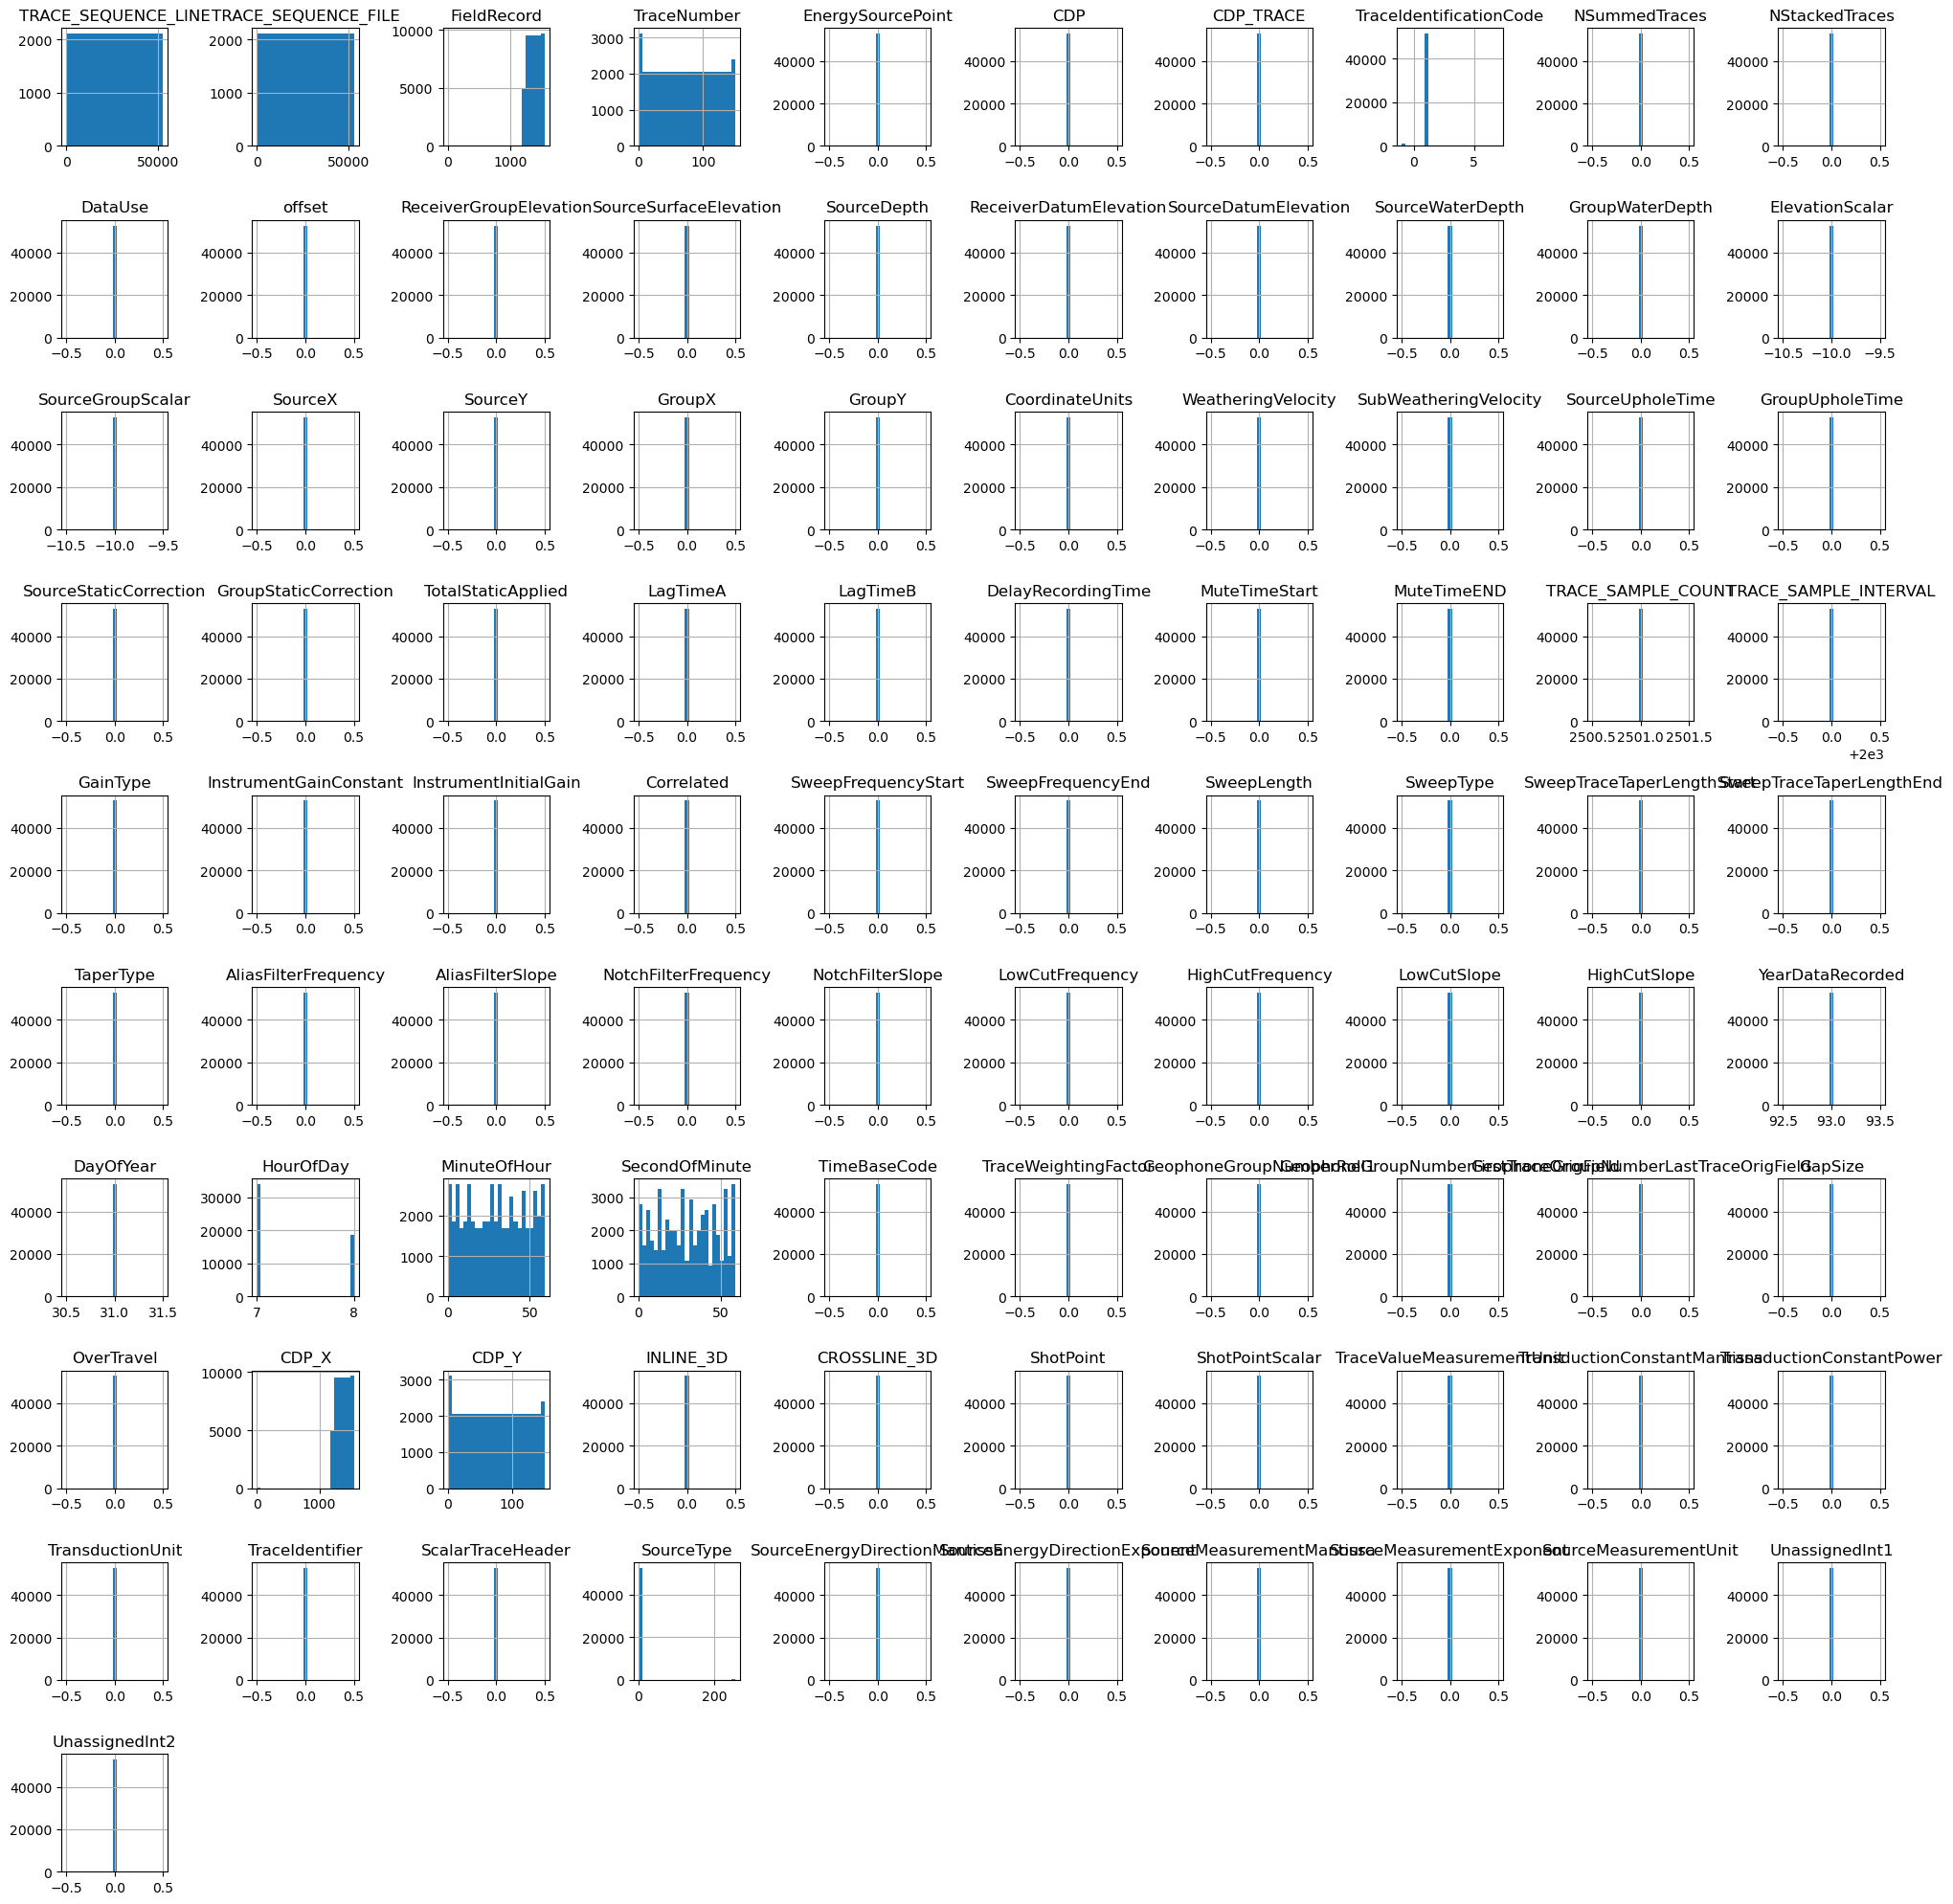

In [68]:
plot = scrape.hist(bins=25, figsize=(20, 20))
plt.tight_layout()
plt.show()

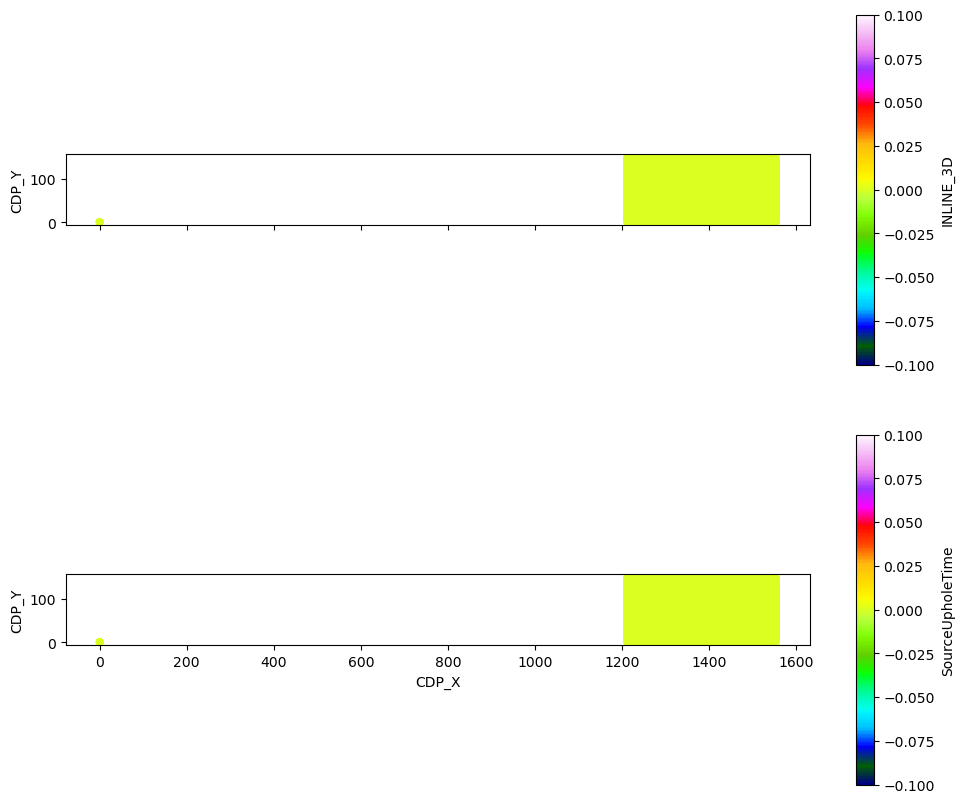

In [74]:
fig, axs = plt.subplots(nrows=2, figsize=(12, 10), sharex=True, sharey=True)

scrape.plot(
    kind="scatter", x="CDP_X", y="CDP_Y", c="INLINE_3D", ax=axs[0], cmap="gist_ncar"
)
scrape.plot(
    kind="scatter", x="CDP_X", y="CDP_Y", c="SourceUpholeTime", ax=axs[1], cmap="gist_ncar"
)
for aa in axs:
    aa.set_aspect("equal", "box")
plt.show()

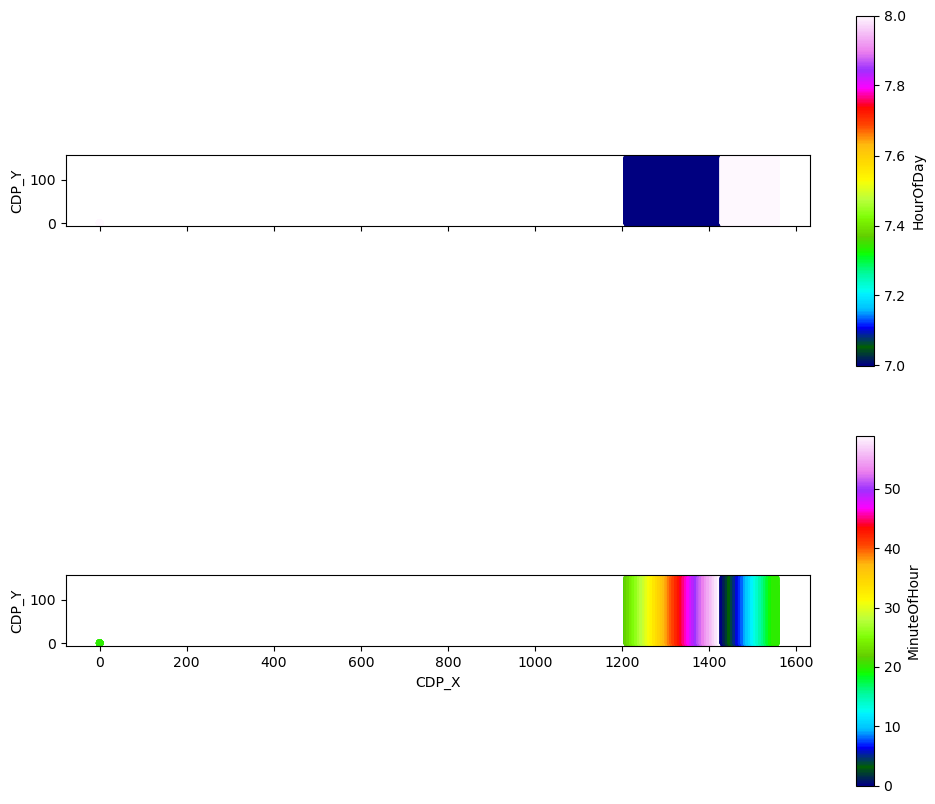

In [73]:
fig, axs = plt.subplots(nrows=2, figsize=(12, 10), sharex=True, sharey=True)

scrape.plot(
    kind="scatter", x="CDP_X", y="CDP_Y", c="HourOfDay", ax=axs[0], cmap="gist_ncar"
)
scrape.plot(
    kind="scatter", x="CDP_X", y="CDP_Y", c="MinuteOfHour", ax=axs[1], cmap="gist_ncar"
)
for aa in axs:
    aa.set_aspect("equal", "box")
plt.show()

In [75]:
ds = xr.open_dataset(segy_file, dim_byte_fields={"iline":189, "xline":193},
    extra_byte_fields={"cdp_x":181, "cdp_y":185})

# remember to scale the coordinate if required
ds.segysak.scale_coords()
_ = ds.segysak.get_affine_transform()

Processing Chunks:   0%|          | 0.00/1.00 [00:00<?, ? trace-chunks/s]

Reading header:   0%|          | 0.00/52.8k [00:00<?, ? traces/s]

ValueError: The selected dimensions results in multiple traces per dimension location, add additional dimensions or use trace numbering byte location to load as 2D.

In [35]:
ds

<xarray.Dataset> Size: 336MB
Dimensions:  (iline: 39403, xline: 1, samples: 2126)
Coordinates:
  * iline    (iline) int32 158kB 420021533 420021534 ... 452920780 453051852
  * xline    (xline) int8 1B 0
  * samples  (samples) float32 9kB 0.0 4.0 8.0 ... 8.492e+03 8.496e+03 8.5e+03
Data variables:
    cdp_x    (iline, xline) float64 315kB 8.147e+07 8.147e+07 ... 8.223e+07
    cdp_y    (iline, xline) float64 315kB 7.331e+08 7.331e+08 ... 7.33e+08
    data     (iline, xline, samples) float32 335MB ...
Attributes:
    seisnc:   {"coord_scalar": 1.0, "coord_scaled": true, "affine": [0.017660...

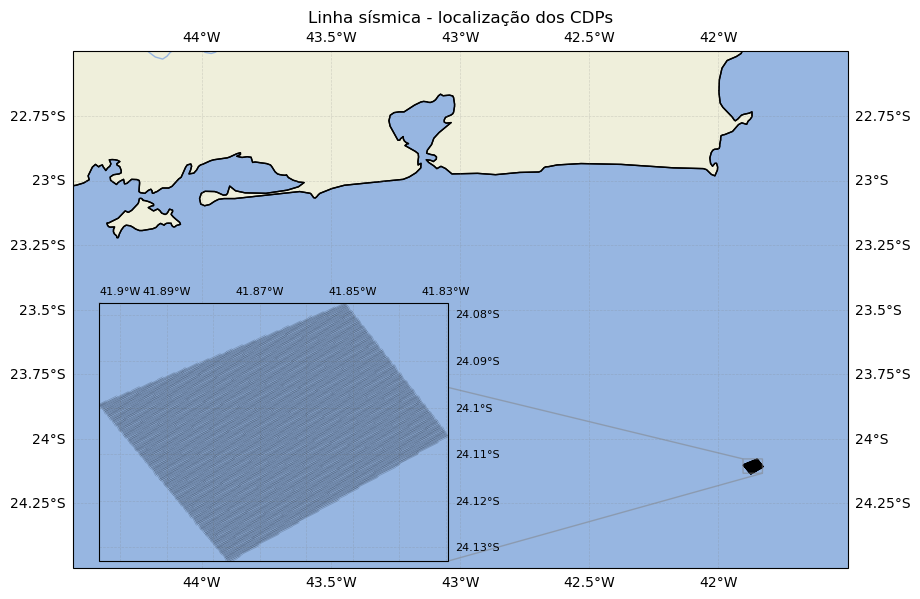

In [36]:
fig, ax = plt.subplots(figsize=(10, 8),subplot_kw=dict(projection=ccrs.PlateCarree()))
# --- Definir recorte do mapa (RJ + região offshore) ---
ax.set_extent([-44.5, -41.5, -24.5, -22.5], crs=ccrs.PlateCarree())  # ajustar conforme seus dados

# Adiciona elementos geográficos
ax.coastlines(resolution='10m')
ax.add_feature(cfeature.LAND, zorder=0, edgecolor='black')
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.LAKES, alpha=0.5)
ax.add_feature(cfeature.RIVERS)

# Plotar linha sísmica
# --- Converter coordenadas UTM (zona 23S) para lat/lon ---

utmx,utmy=ds.cdp_x.values.flatten()/100,ds.cdp_y.values.flatten()/100
proj_utm = pyproj.Proj(proj='utm', zone=23, south=True, ellps='WGS84')
lon, lat = proj_utm(utmx,utmy, inverse=True)

ax.plot(lon, lat,'.k', markersize=0.01, label='CDPs')

ax.set_title('Linha sísmica - localização dos CDPs')
ax.gridlines(draw_labels=True, crs=ccrs.PlateCarree(),linewidth=0.5, color='gray', alpha=0.25, linestyle='--')

# --- criar inset com projeção ---
axins = inset_axes(ax, width="50%", height="50%", loc='lower left',
                   axes_class=GeoAxes,
                   axes_kwargs=dict(projection=ccrs.PlateCarree()))

gl = axins.gridlines(draw_labels=True, crs=ccrs.PlateCarree(),linewidth=0.5, color='gray', alpha=0.25, linestyle='--')
# Grade com apenas topo e direita
gl.top_labels = True
gl.right_labels = True
gl.bottom_labels = False
gl.left_labels = False
gl.xlabel_style = {'size': 8}
gl.ylabel_style = {'size': 8}

# Mapa do inset
x1, x2, y1, y2 = lon.min(), lon.max(), lat.min(), lat.max()
axins.set_xlim(x1, x2)
axins.set_ylim(y1, y2)

# Adiciona elementos geográficos
axins.coastlines(resolution='10m')
axins.add_feature(cfeature.LAND, zorder=0, edgecolor='black')
axins.add_feature(cfeature.OCEAN)
axins.add_feature(cfeature.BORDERS, linestyle=':')
axins.add_feature(cfeature.LAKES, alpha=0.5)
axins.add_feature(cfeature.RIVERS)

axins.plot(lon, lat, '.k', markersize=0.1)

# Conectar zoom (opcional)
ax.indicate_inset_zoom(axins)

plt.show()


In [37]:
ds.head(5)

<xarray.Dataset> Size: 221B
Dimensions:  (iline: 5, xline: 1, samples: 5)
Coordinates:
  * iline    (iline) int32 20B 420021533 420021534 420021535 420021536 420152605
  * xline    (xline) int8 1B 0
  * samples  (samples) float32 20B 0.0 4.0 8.0 12.0 16.0
Data variables:
    cdp_x    (iline, xline) float64 40B 8.147e+07 8.147e+07 ... 8.147e+07
    cdp_y    (iline, xline) float64 40B 7.331e+08 7.331e+08 ... 7.331e+08
    data     (iline, xline, samples) float32 100B ...
Attributes:
    seisnc:   {"coord_scalar": 1.0, "coord_scaled": true, "affine": [0.017660...

In [38]:
ds.keys()

KeysView(<xarray.Dataset> Size: 336MB
Dimensions:  (iline: 39403, xline: 1, samples: 2126)
Coordinates:
  * iline    (iline) int32 158kB 420021533 420021534 ... 452920780 453051852
  * xline    (xline) int8 1B 0
  * samples  (samples) float32 9kB 0.0 4.0 8.0 ... 8.492e+03 8.496e+03 8.5e+03
Data variables:
    cdp_x    (iline, xline) float64 315kB 8.147e+07 8.147e+07 ... 8.223e+07
    cdp_y    (iline, xline) float64 315kB 7.331e+08 7.331e+08 ... 7.33e+08
    data     (iline, xline, samples) float32 335MB ...
Attributes:
    seisnc:   {"coord_scalar": 1.0, "coord_scaled": true, "affine": [0.017660...)

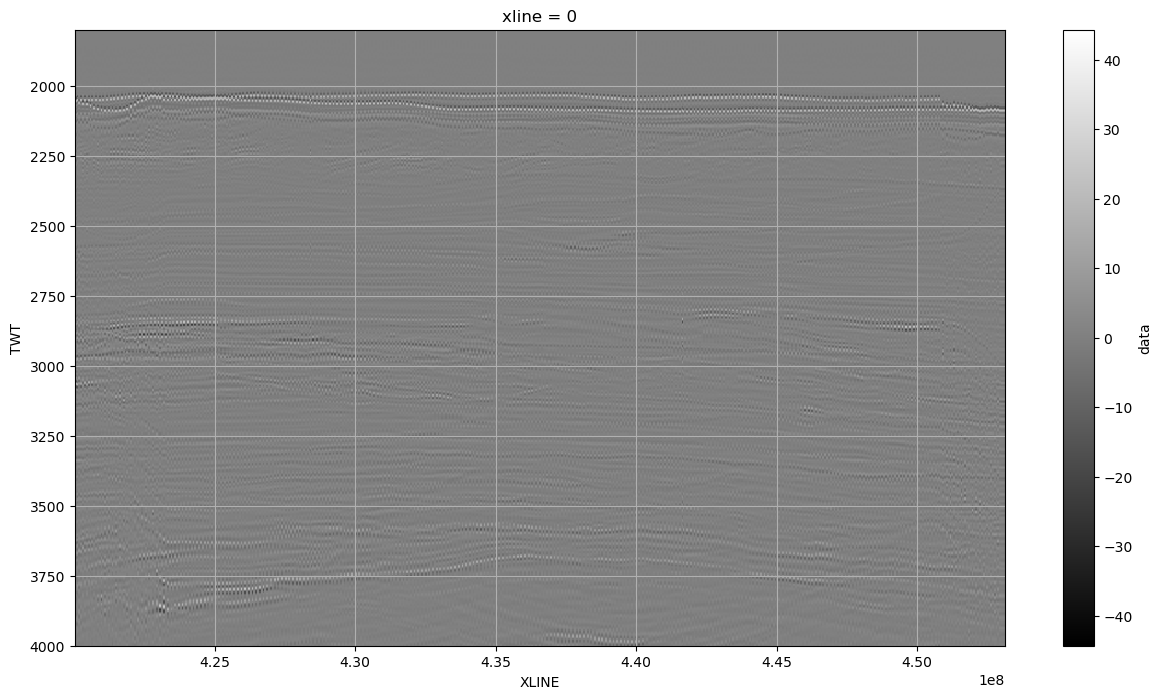

In [62]:
fig, ax1 = plt.subplots(ncols=1, figsize=(15, 8))
ds.data.transpose("samples", "iline", "xline", transpose_coords=True).plot(yincrease=False, cmap="grey")
plt.grid("grey")
plt.ylabel("TWT")
plt.xlabel("XLINE")
plt.ylim(4000,1800)
plt.show()

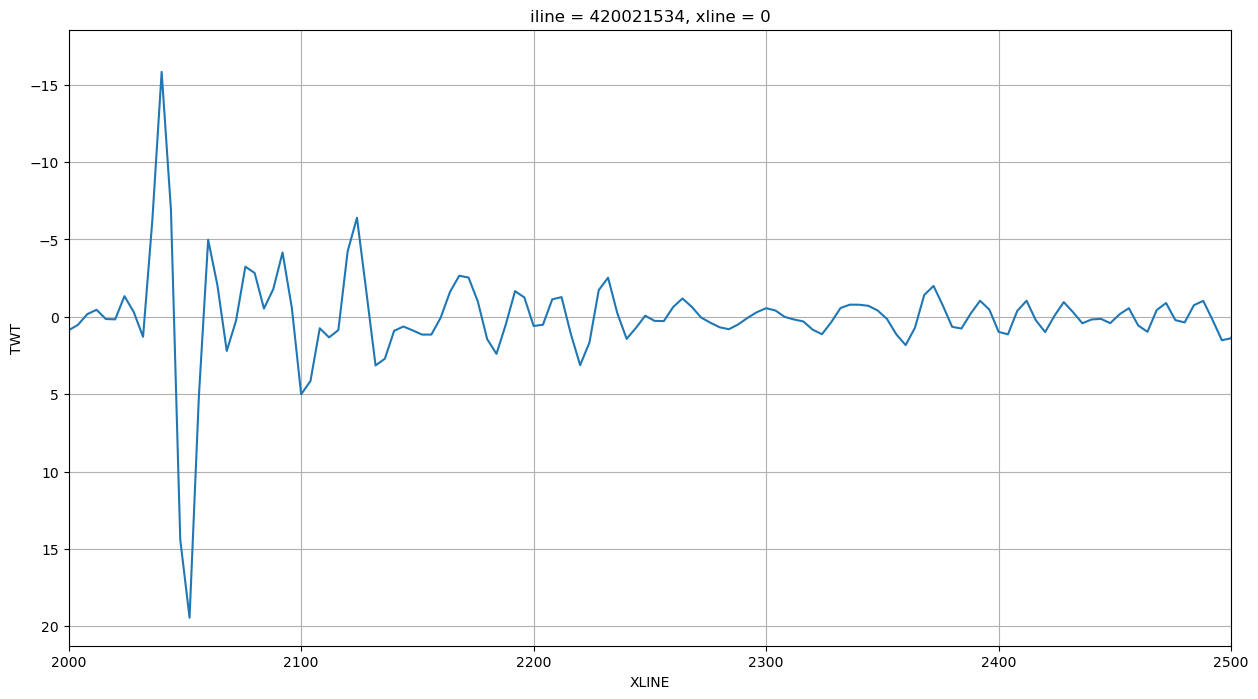

In [51]:
fig, ax1 = plt.subplots(ncols=1, figsize=(15, 8))
iline_sel = 420021534
ds.data.transpose("samples", "iline", "xline", transpose_coords=True).sel(
    iline=iline_sel
).plot(yincrease=False)
plt.grid("grey")
plt.xlim(2000,2500)
plt.ylabel("TWT")
plt.xlabel("XLINE")
plt.show()

In [52]:
def bandpass_filter(trace, fs, lowcut, highcut, order=4):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, trace)

In [53]:
def filter_dataset_bandpass_ufunc(ds, var="data", fs=250, lowcut=5, highcut=30, order=4):
    """
    Aplica filtro bandpass à variável `var` de um xarray.Dataset 3D (iline, xline, samples)
    sem remover dimensões. Retorna novo Dataset com variável filtrada.
    """
    da = ds[var]

    # Aplica o filtro ao longo da dimensão "samples"
    da_filtered = xr.apply_ufunc(
        bandpass_filter,
        da,
        input_core_dims=[["samples"]],
        output_core_dims=[["samples"]],
        kwargs={"fs": fs, "lowcut": lowcut, "highcut": highcut, "order": order},
        vectorize=True,
        dask="allowed",
        output_dtypes=[da.dtype]
    )

    # Cria cópia do Dataset com a variável filtrada
    ds_filtered = ds.copy()
    ds_filtered[var] = da_filtered

    return ds_filtered

In [54]:
ds_filtered = filter_dataset_bandpass_ufunc(ds, var="data", fs=250, lowcut=5, highcut=50)

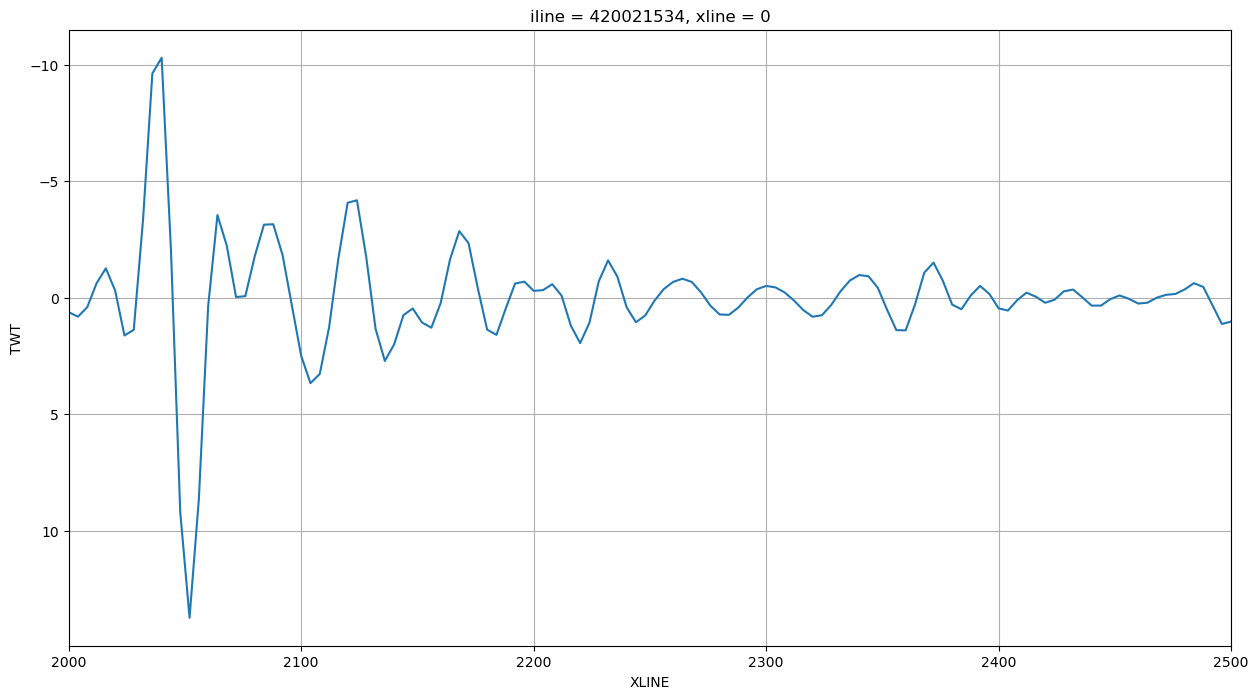

In [55]:
fig, ax1 = plt.subplots(ncols=1, figsize=(15, 8))
iline_sel = 420021534
ds_filtered.data.transpose("samples", "iline", "xline", transpose_coords=True).sel(
    iline=iline_sel
).plot(yincrease=False)
plt.grid("grey")
plt.ylabel("TWT")
plt.xlabel("XLINE")
plt.xlim(2000,2500)
plt.show()

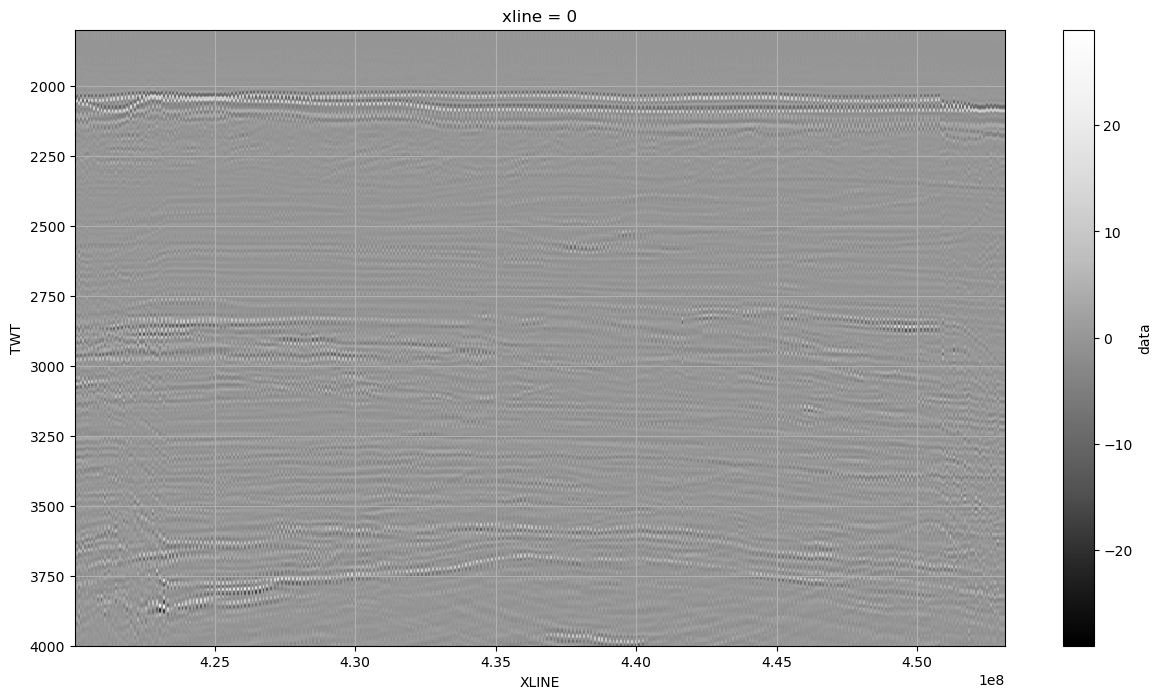

In [61]:
fig, ax1 = plt.subplots(ncols=1, figsize=(15, 8))
ds_filtered.data.transpose("samples", "iline", "xline", transpose_coords=True).plot(yincrease=False, cmap="Grays_r")
plt.grid("grey")
plt.ylabel("TWT")
plt.xlabel("XLINE")
plt.ylim(4000,1800)
plt.show()